#What drives the price of the world's rarest gemstones? — An exploratory data analysis through webscraping

In [ ]:
!pip install beautifulsoup4 lxml --quiet

In [ ]:
#first, I am importing the libraries and tools I need
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# next, I am defining the gemstones I am interested in collecting data on, and changing their spelling to
#notation that is easier to understand for the computer, to avoid potential complications later on.
#I am also defining the url variable for the website I want to scrape, and am using a mode of impersonation my tutor reccommended for the headers variable.
#this is so that the website does not suspect us of scraping and thinks we are a normal browser
gems = {
    'Paraiba Tourmaline' : 'paraiba-tourmaline',
    'Alexandrite'        : 'alexandrite',
    'Demantoid Garnet'   : 'demantoid-garnet',
    'Tanzanite'          : 'tanzanite',
}

base_url = 'https://naturalgemstones.com'
headers  = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}


In [ ]:
#now, I am sourcing the individual web urls for each individual stone we want in our dataframe.
#some span many pages on the website, so we set a range, a mode of compiling them,
#and also adding in a timed break at the bottom to give the computer a rest, this is important.
all_links = []

for gem_name, gem_slug in gems.items():
    print('Collecting:', gem_name)

    for page in range(1, 11):

        if page == 1:
            url = f'{base_url}/{gem_slug}/'
        else:
            url = f'{base_url}/{gem_slug}/?page={page}'

        response    = requests.get(url, headers=headers, timeout=15)
        soup        = BeautifulSoup(response.text, 'lxml')
        links_found = []

        for tag in soup.find_all('a', href=True):
            link = tag['href']
            if gem_slug in link and link.count('/') >= 3 and 'page=' not in link:
                if link not in links_found:
                    links_found.append(link)

        if len(links_found) == 0:
            break

        print(f'  page {page}: {len(links_found)} stones')

        for link in links_found:
            all_links.append({'gem_type': gem_name, 'url': base_url + link})

        time.sleep(1.5)

print('Total links:', len(all_links))


Collecting: Paraiba Tourmaline
  page 1: 60 stones
  page 2: 22 stones
Collecting: Alexandrite
  page 1: 60 stones
  page 2: 60 stones
  page 3: 60 stones
  page 4: 60 stones
  page 5: 32 stones
Collecting: Demantoid Garnet
  page 1: 60 stones
  page 2: 60 stones
  page 3: 19 stones
Collecting: Tanzanite
  page 1: 60 stones
  page 2: 60 stones
  page 3: 60 stones
  page 4: 5 stones
Total links: 678


In [ ]:
# this is the actual coded webscraper, where I am now scraping all of the urls
#the code has compiled to collect the data on the 12 categories we want for our dataframe.

session = requests.Session()
session.headers.update({'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'})

rows = []

for i, item in enumerate(all_links):
    try:
        response = session.get(item['url'], timeout=15)
        soup     = BeautifulSoup(response.text, 'lxml')
        table    = soup.find('table')

        # in case there is an error, this tells the computer to wait and them try again,
        # as initial versions of the webscraper did not work and stopped early
        if table is None:
            time.sleep(random.uniform(15, 25))
            response = session.get(item['url'], timeout=15)
            soup     = BeautifulSoup(response.text, 'lxml')
            table    = soup.find('table')

        if table is None:
            continue

        stone = {'gem_type': item['gem_type'], 'url': item['url']}

        for row in table.find_all('tr'):
            th = row.find('th')
            td = row.find('td')
            if th is None or td is None:
                continue

            label = th.get_text(strip=True).replace('help', '').replace(':', '').strip()
            value = td.get_text(separator=' ', strip=True)

            if   label == 'Item ID':
              stone['item_id'] = value
            elif label == 'Dimensions (MM)':
              stone['dimensions_mm'] = value
            elif label == 'Weight':
              stone['weight_ct'] = value.replace('Ct.', '').strip()
            elif label == 'Color':
              stone['color'] = value
            elif label == 'Color intensity':
              stone['color_intensity'] = value
            elif label == 'Clarity':
              stone['clarity'] = value
            elif label == 'Shape':
              stone['shape'] = value
            elif label == 'Cut':
               stone['cut'] = value
            elif label == 'Cutting style':
              stone['cutting_style'] = value
            elif label == 'Enhancements':
              stone['enhancements'] = value
            elif label == 'Origin':
              stone['origin']= value
            elif label == 'Per carat price':
              stone['per_carat_price_usd'] = value.replace('$', '').replace(',', '').strip()

        rows.append(stone)

    except Exception as e:
        print(f'skipped {i+1}: {e}')

    # because this scraper will probably take a time to complete, this will save the progress every 50 stones so not all the data is lost if it stops
    if (i + 1) % 50 == 0:
        pd.DataFrame(rows).to_csv('rare_gems.csv', index=False)
        print(f'{i+1} / {len(all_links)} done — {len(rows)} collected')

    # here we are also putting in random wait/pause times, so that it seems like a person, not a computer, is browsing
    time.sleep(random.uniform(2, 5))

print('yeehaw its done! collected', len(rows), 'stones')


50 / 678 done — 50 collected
100 / 678 done — 100 collected
150 / 678 done — 150 collected
200 / 678 done — 200 collected
250 / 678 done — 250 collected
300 / 678 done — 300 collected
350 / 678 done — 350 collected
400 / 678 done — 400 collected
450 / 678 done — 450 collected
500 / 678 done — 500 collected
550 / 678 done — 550 collected
600 / 678 done — 600 collected
650 / 678 done — 650 collected
yeehaw its done! collected 678 stones


In [ ]:
# Now I will construct the actual dataframe, and save as a csv for easier access later on,
# and am converting the stone weight and price to numbers, and calculating their total prices to to be able to do calculations later

df = pd.DataFrame(rows)
df['weight_ct'] = pd.to_numeric(df['weight_ct'], errors='coerce')
df['per_carat_price_usd'] = pd.to_numeric(df['per_carat_price_usd'], errors='coerce')
df['total_price_usd'] = df['weight_ct'] * df['per_carat_price_usd']

df = df[[
    'gem_type', 'item_id',
    'weight_ct', 'per_carat_price_usd', 'total_price_usd',
    'color', 'color_intensity', 'clarity',
    'shape', 'cut', 'cutting_style',
    'enhancements', 'origin', 'dimensions_mm',
    'url'
]]

df.to_csv('rare_gems.csv', index=False)

print(f'Saved to rare_gems.csv')
print(f'Rows: {len(df)}   Columns: {len(df.columns)}')
print(f'\nStones per gem type:')
print(df['gem_type'].value_counts())

df.head(10)

Saved to rare_gems.csv
Rows: 678   Columns: 15

Stones per gem type:
gem_type
Alexandrite           272
Tanzanite             185
Demantoid Garnet      139
Paraiba Tourmaline     82
Name: count, dtype: int64


,gem_type,item_id,weight_ct,per_carat_price_usd,total_price_usd,color,color_intensity,clarity,shape,cut,cutting_style,enhancements,origin,dimensions_mm,url
0,Paraiba Tourmaline,K3536,6.08,46000,279680.0,Greenish Blue,Intense,Slightly Included,Oval,Mixed Brilliant,Faceted,Heat Treated,Brazil,Length: 12.76 Width: 10.12 Height: 7.23,https://naturalgemstones.com/paraiba-tourmalin...
1,Paraiba Tourmaline,K6042,2.00,21750,43500.0,Greenish Blue,Medium,Very Slightly Included,Pear,Mixed Brilliant,Faceted,No Enhancement,Mozambique,Length: 10.96 Width: 6.63 Height: 4.94,https://naturalgemstones.com/paraiba-tourmalin...
2,Paraiba Tourmaline,K3427,3.43,13050,44761.5,Bluish Green,Medium,Very Slightly Included,Oval,Mixed Brilliant,Faceted,Heat Treated,Africa,Length: 11.92 Width: 8.45 Height: 5.53,https://naturalgemstones.com/paraiba-tourmalin...
3,Paraiba Tourmaline,K3428,0.86,19800,17028.0,Bluish Green,Intense,Slightly Included,Oval,Mixed Brilliant,Faceted,Heat Treated,Brazil,Length: 8.13 Width: 5.23 Height: 2.97,https://naturalgemstones.com/paraiba-tourmalin...
4,Paraiba Tourmaline,K5727,8.43,1700,14331.0,Bluish Green,Medium,Slightly Included,Oval,Double Cabochon,Cabochon,Heat Treated,Brazil,Length: 13.2 Width: 10.74 Height: 7.19,https://naturalgemstones.com/paraiba-tourmalin...
5,Paraiba Tourmaline,K2478,1.82,8500,15470.0,Bluish Green,Medium,Eye Clean,Oval,Mixed Brilliant,Faceted,Heat Treated,Mozambique,Length: 9.31 Width: 6.38 Height: 4.74,https://naturalgemstones.com/paraiba-tourmalin...
6,Paraiba Tourmaline,K3430,14.45,17250,249262.5,Greenish Blue,Intense,Very Slightly Included,Cushion,Mixed Brilliant,Faceted,Heat Treated,Africa,Length: 15.01 Width: 14.8 Height: 9.78,https://naturalgemstones.com/paraiba-tourmalin...
7,Paraiba Tourmaline,K5112,2.13,21700,46221.0,Greenish Blue,Medium,Eye Clean,Pear,Mixed Brilliant,Faceted,Heat Treated,Mozambique,Length: 11.01 Width: 6.87 Height: 5.06,https://naturalgemstones.com/paraiba-tourmalin...
8,Paraiba Tourmaline,K4861,0.89,33000,29370.0,Greenish Blue,Intense,Eye Clean,Round,Mixed Brilliant,Faceted,Heat Treated,Brazil,Length: 6.03 Width: 6.01 Height: 4.3,https://naturalgemstones.com/paraiba-tourmalin...
9,Paraiba Tourmaline,K5108,1.10,43500,47850.0,Greenish Blue,Intense,Very Slightly Included,Cushion,Mixed Brilliant,Faceted,Heat Treated,Brazil,Length: 6.95 Width: 5.97 Height: 3.89,https://naturalgemstones.com/paraiba-tourmalin...


In [ ]:
# Here I am doing the basic info check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678 entries, 0 to 677
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gem_type             678 non-null    object 
 1   item_id              678 non-null    object 
 2   weight_ct            678 non-null    float64
 3   per_carat_price_usd  678 non-null    int64  
 4   total_price_usd      678 non-null    float64
 5   color                678 non-null    object 
 6   color_intensity      678 non-null    object 
 7   clarity              678 non-null    object 
 8   shape                678 non-null    object 
 9   cut                  678 non-null    object 
 10  cutting_style        678 non-null    object 
 11  enhancements         678 non-null    object 
 12  origin               678 non-null    object 
 13  dimensions_mm        678 non-null    object 
 14  url                  678 non-null    object 
dtypes: float64(2), int64(1), object(12)
memo

In [ ]:
# and here I am calculating the basic stats of our data
df[['weight_ct', 'per_carat_price_usd', 'total_price_usd']].describe().round(2)

,weight_ct,per_carat_price_usd,total_price_usd
count,678.00,678.00,678.00
mean,3.38,5013.15,12225.49
std,8.81,8019.73,35209.95
min,0.16,101.00,136.00
25%,0.71,821.25,1036.87
50%,1.30,2379.50,2658.00
75%,2.75,4800.00,9172.76
max,159.41,74750.00,460395.00


In [ ]:
# here I am checking for any missing values(by column) to checks correctness of the data,
#which is needed to make sure nonexistent values dont impact results and we can cut the full rows if needed
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
gem_type               0
item_id                0
weight_ct              0
per_carat_price_usd    0
total_price_usd        0
color                  0
color_intensity        0
clarity                0
shape                  0
cut                    0
cutting_style          0
enhancements           0
origin                 0
dimensions_mm          0
url                    0
dtype: int64


In [ ]:
# for the first calculation of
print('Median price per carat (USD) by gem type:')
print(df.groupby('gem_type')['per_carat_price_usd'].median().sort_values(ascending=False).round(0))

Median price per carat (USD) by gem type:
gem_type
Paraiba Tourmaline    9250.0
Alexandrite           3574.0
Demantoid Garnet      3120.0
Tanzanite              570.0
Name: per_carat_price_usd, dtype: float64


In [ ]:
#df = pd.read_csv('rare_gems.csv')
#print(f'Loaded {len(df)} rows')
#df.head()

In [ ]:
# now we get into the data visualization

/tmp/ipykernel_5394/135036818.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=origin_df, x='origin', y='per_carat_price_usd', palette='Set2')


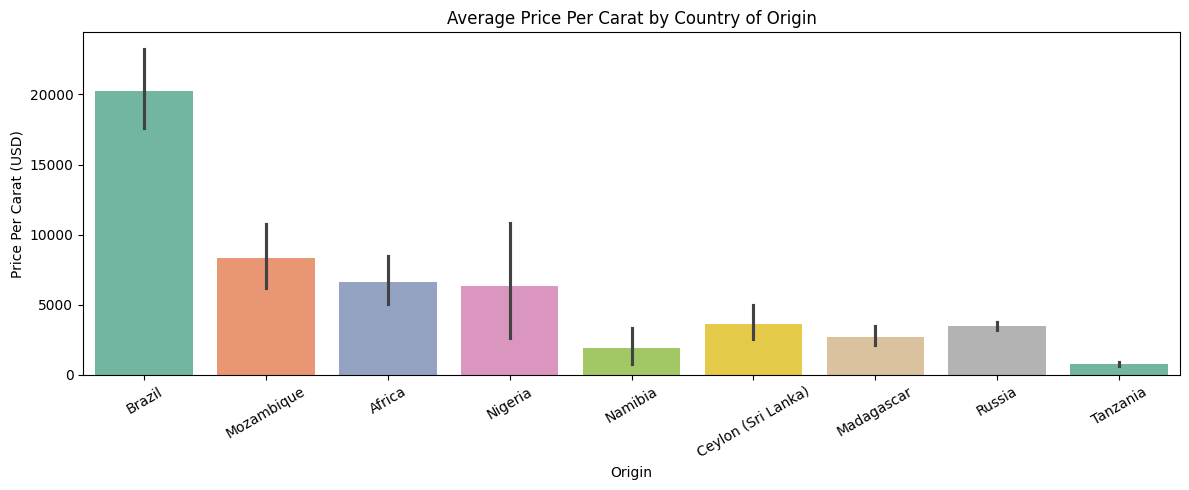

In [ ]:
# for our first visualisation, I am creating a bar plot on the average price per carat by country of origin
origin_counts  = df['origin'].value_counts()
common_origins = origin_counts[origin_counts >= 5].index
origin_df      = df[df['origin'].isin(common_origins)]

plt.figure(figsize=(12, 5))
sns.barplot(data=origin_df, x='origin', y='per_carat_price_usd', palette='Set2')
plt.title('Average Price Per Carat by Country of Origin')
plt.xlabel('Origin')
plt.ylabel('Price Per Carat (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



In [ ]:
# Brazilian stones have the highest average price per carat. The country sits at $20,000 per carat
#and significantly exceeds all other regions. That gap is almost entirely
# due to Paraiba Tourmaline pulling the average up, since Brazilian Paraiba is the original and most sought-after origin
# in the gemstone and jewely industry. .

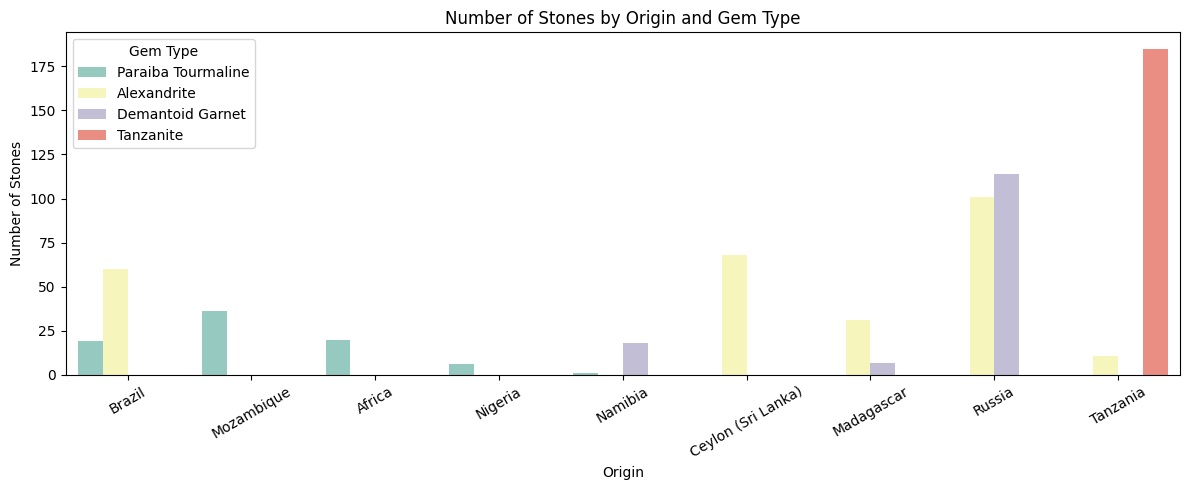

In [ ]:
# Next, I am looking at the actual output of gemstones by type and country, to see how their mining is distributed.
plt.figure(figsize=(12, 5))
sns.countplot(data=origin_df, x='origin', hue='gem_type', palette='Set3')
plt.title('Number of Stones by Origin and Gem Type')
plt.xlabel('Origin')
plt.ylabel('Number of Stones')
plt.xticks(rotation=30)
plt.legend(title='Gem Type')
plt.tight_layout()
plt.show()


In [ ]:
# Tanzania dominates in volume with nearly 185 Tanzanite stones,
#while Brazilian Paraiba has only around 20 listings — which perfectly illustrates the industries supply dynamic:
#the rarest stones have the fewest listings and the highest prices.
#Russia and Tanzania have the highest number of stones,
#and practically own the categories of dematoid garnet and tanzanite.
#Altough Paraibas are represented by different countries,
#it is interesing how Brazilian stones are fewer but still represent much more relative value,
# as established in our first plot.

/tmp/ipykernel_5394/4175548964.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cutting_style', y='per_carat_price_usd', palette='pastel')


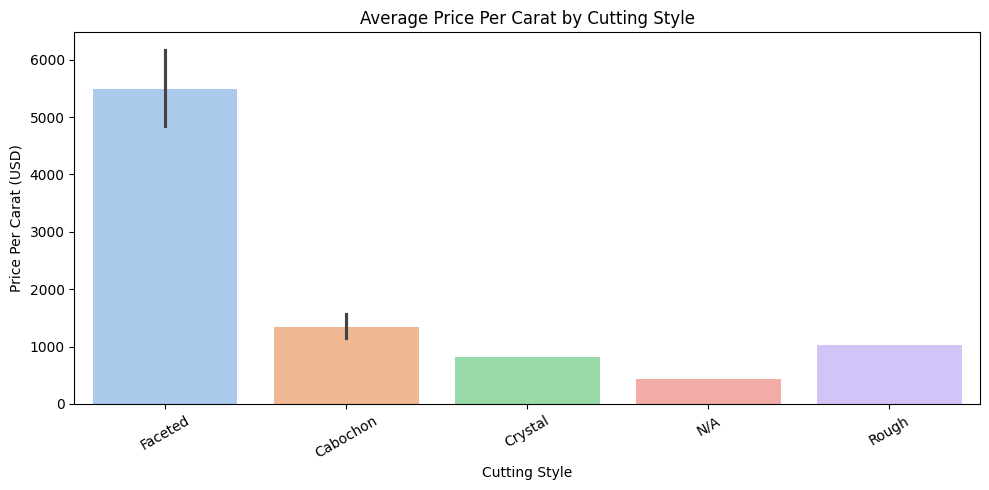

In [ ]:
# Now we are making another bar plot to investigate popularity and effect on price per carat of cutting style.
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='cutting_style', y='per_carat_price_usd', palette='pastel')
plt.title('Average Price Per Carat by Cutting Style')
plt.xlabel('Cutting Style')
plt.ylabel('Price Per Carat (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
# Faceted stones (of different styles) demonstrate the command of a higher price,
# which is not surprising, as faceting is the most labor intensive processing,
# and commonly used on higher quality materials to get the most best out of them.
#Faceted stones average over $5,500 per carat, versus under $1,500 for everything else-


/tmp/ipykernel_5394/1726101905.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='color_intensity', y='per_carat_price_usd', palette='coolwarm')


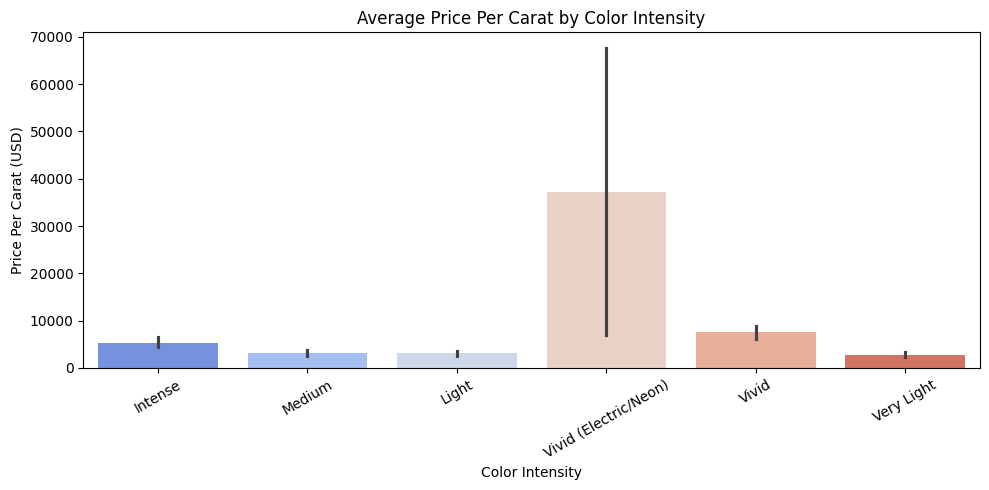

In [ ]:
# Next, I am curious to see how color intensity plays into the pricing of these rare stones, as color,
# in different ways is one of the key value drivers of stones and highly specified.
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='color_intensity', y='per_carat_price_usd', palette='coolwarm')
plt.title('Average Price Per Carat by Color Intensity')
plt.xlabel('Color Intensity')
plt.ylabel('Price Per Carat (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
# Vivid and intense stones appear as the most expensive and stronger color
#saturation is one of the key value drivers for across the board.
#Vivid, Electric and Neon Hues almost surpass the chart at ~$37,000 per carat.
# that category is most likely also credited to Paraiba's.

/tmp/ipykernel_5394/327510250.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='clarity', y='per_carat_price_usd', palette='Blues_d')


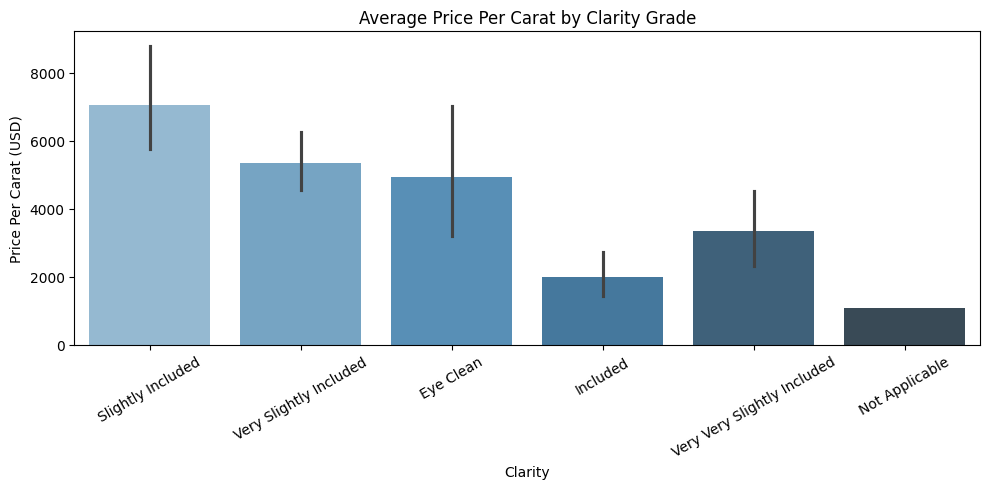

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='clarity', y='per_carat_price_usd', palette='Blues_d')
plt.title('Average Price Per Carat by Clarity Grade')
plt.xlabel('Clarity')
plt.ylabel('Price Per Carat (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
#This figure is probably the most interesting becuase it is surprising
#and actually counterintuitive.
#Slightly Included stones average the highest price,
#which tells you that clarity alone isn't the main driver here.

/tmp/ipykernel_5394/976586854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cut', y='per_carat_price_usd', palette='muted')


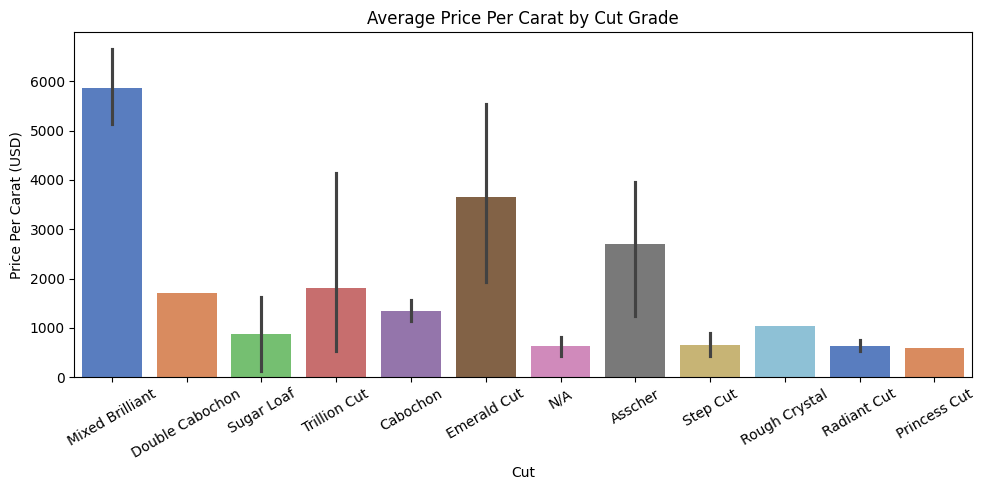

In [ ]:
#For our final bar plot, it would be interesting to see how the cut quality and complexity will affect price for these specific stones.
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='cut', y='per_carat_price_usd', palette='muted')
plt.title('Average Price Per Carat by Cut Grade')
plt.xlabel('Cut')
plt.ylabel('Price Per Carat (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



In [ ]:
# Complex cuts and facets such as brilliants command the highest prices.
#cut quality and complexity reflects the skill of the lapidary(stone cutters) and affects brilliance of the stone.

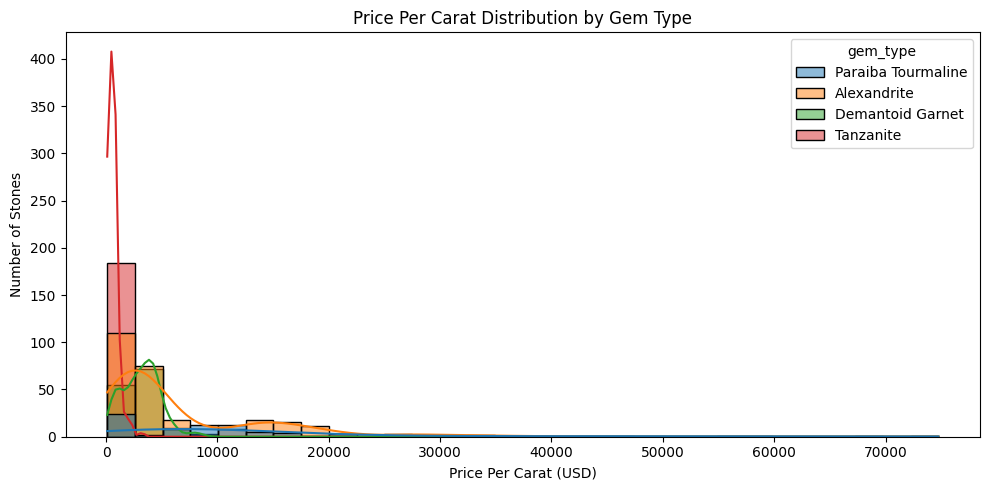

In [ ]:
# Now lets look at the more specific districbution of price per carat distribution by gem type.
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='per_carat_price_usd', hue='gem_type', bins=30, kde=True)
plt.title('Price Per Carat Distribution by Gem Type')
plt.xlabel('Price Per Carat (USD)')
plt.ylabel('Number of Stones')
plt.tight_layout()
plt.show()


In [ ]:
# Here, almost every stone sits under $5,000 per carat,
# but Paraiba has this long tail stretching all the way to $70,000
# defining a small number of exceptional stones that exist in a completely different price
#category to all others in this dataset.

/tmp/ipykernel_5394/3723406332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gem_type', y='weight_ct', palette='Set2')


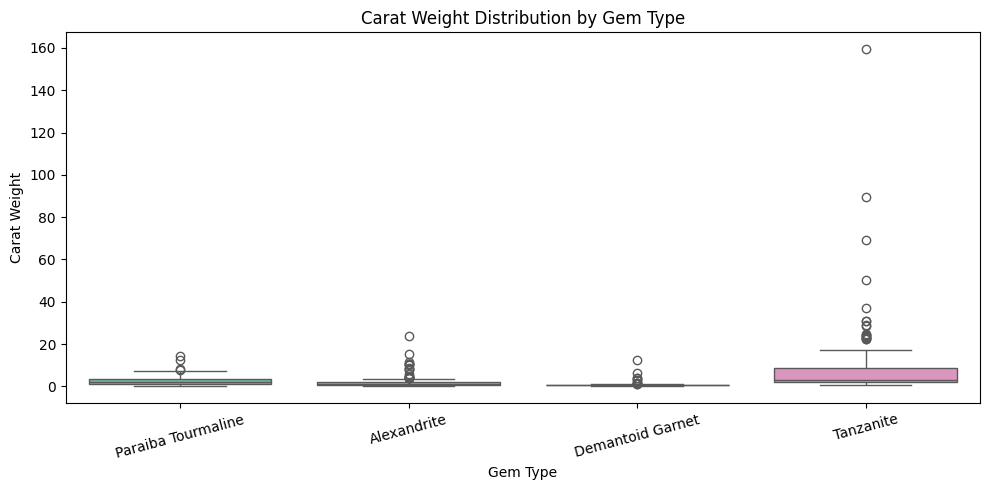

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='gem_type', y='weight_ct', palette='Set2')
plt.title('Carat Weight Distribution by Gem Type')
plt.xlabel('Gem Type')
plt.ylabel('Carat Weight')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Tanzanite tends to come in larger sizes, while Paraiba Tourmalines are typically smaller — which makes large Paraibas exceptionally rare and valuable.


In [ ]:
#Tanzanite comes in dramatically larger sizes than the other three gemstone types
# with outliers reaching 160 carats, while Paraiba, Alexandrite, and Demantoid are all
# typically tiny stones, falling under 3 carats.
#The fact that Paraiba is both the smallest and the most expensive per carat is
#what again marks it as the rarest and most extraodinary out of the stones
#sampled in this investigation.

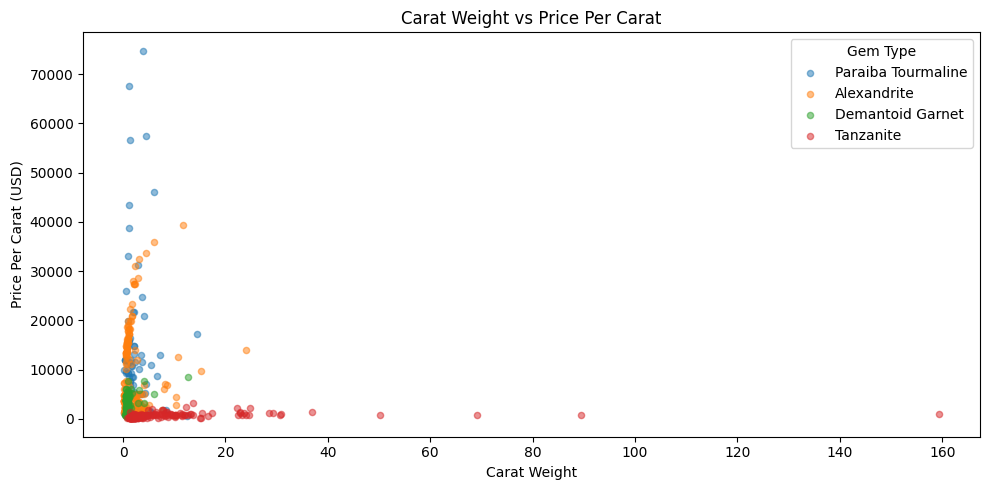

In [ ]:
plt.figure(figsize=(10, 5))
for gem in df['gem_type'].unique():
    subset = df[df['gem_type'] == gem]
    plt.scatter(subset['weight_ct'], subset['per_carat_price_usd'], label=gem, alpha=0.5, s=20)

plt.title('Carat Weight vs Price Per Carat')
plt.xlabel('Carat Weight')
plt.ylabel('Price Per Carat (USD)')
plt.legend(title='Gem Type')
plt.tight_layout()
plt.show()



In [ ]:
#Here, Paraiba sits almost entirely on the left with tiny stones,
#yet reaches the highest prices per carat by far, reinforcing that its value
#has nothing to do with size and everything to do with what it is.
#Tanzanite is the opposite: it comes in massive sizes but flatlines near zero per carat,
# which tells you it's abundant enough that weight alone doesn't make it more valuable.

#Executive Summary




Anna Léonie Ritvay: Python Midterm


What Drives the Price of the World's Rarest Gemstones? — An Exploratory Data Analysis Through Webscraping


This project explores what drives the price of four distinct gemstones, classified as some of the rarest in the world: Paraiba Tourmaline, Alexandrite, Demantoid Garnet, and Tanzanite, through the scraping of data from naturalgemstones.com, one of the only online retailers selling stones at that value with detailed SKU information. The dataframe covers 678 individual stones with 12 factors per stone, which include weight, origin, clarity, color intensity, cut, cutting style, and treatment status. The central variable to this exploration is the price per carat, the standard unit of comparison in gemology and the jewelry industry, as it normalizes for size and allows for comparison that is adjusted, meaningful, and actionable across stones of different weights and classes.


I initially wanted to create a dataset exclusively focused on Paraiba tourmalines, which I have handled as a rookie jeweler and when shadowing in the diamond district and which I am specifically interested in. They are known for their range of vivid turquoise colors that stems from their copper content and are sourced from three regions globally, primarily in Brazil, and can be more expensive than diamonds. Paraíbas are so rare that there are no comprehensive existing datasets, which is why I wanted to challenge myself to build my own and combine my interests by approaching the research through a consulting frame by investigating price drivers. However, because they are so rare, I realized it would not be feasible to source sufficient data from a single website to create a dataframe of 300 rows and decided to expand the scope to include other rare gemstone varieties and instead explore what drives their prices and how they compare.


I felt that scraping would be both the most challenging and exciting mode of sourcing data and worked in tandem with my tutor, friends, and my brother who have backgrounds in computer science, to construct this project, whom I would like to credit at this point for helping me structure my approaches and supporting my learnings and comprehension, especially in writing the scraper and creating more attractive visualizations.


The most consistent finding is that Paraiba Tourmaline commands a significantly higher price per carat than the other three gem types. Brazilian-origin stones — dominated by Paraiba — averaged $20,300 per carat , compared to $8,500 per carat for Mozambique, $6,300 per carat for Nigeria, $3,800 per carat for Ceylon, and $700 per carat for Tanzania. This premium holds even though Paraibas in this dataset tend to be smaller stones, which in most markets would suppress per-carat pricing. That gap reflects the legitimacy of their rarity: the neon color, attributed to copper content, is specific to only three mining origins globally and cannot be replicated in any other gem variety.
Origin emerged as one of the strongest price drivers overall, though its effect varied across gem types. For Paraiba, the Brazilian premium is clear and dramatic. For Alexandrite, Sri Lankan and Brazilian stones similarly led on price. Tanzanite, by contrast, is sourced exclusively from one region in Tanzania, so there is no origin differentiation to factor in, and with 185 listings versus roughly 20 for Brazilian Paraiba, the volume alone tells you something about relative scarcity.


Color intensity was one of the most striking findings in the data. Vivid (electric/neon) stones, a category that essentially captures Paraiba's neon copper-blue, averaged $37,000 per carat, against $7,500 per carat for vivid, $5,500 carat for intense, and around $3,000 per carat for medium and light stones. That colour category exists almost exclusively because of Paraiba, and the market has priced it accordingly. In colored gemstone grading, colour saturation is always the primary value driver, and the data clearly reflects that.
Treatment status had a consistent effect across all four gem types—untreated stones commanded a premium across the board, not just within one category, which tells you that the market has a shared and stable understanding of what natural colour is worth. The pattern held regardless of gem type rather than being driven by one outlier.


Carat weight was the strongest single predictor of total price, and its relationship with price per carat was also positive. This indicates that buyers pay a higher per-carat rate for larger stones, not just a higher total. This, in turn, reflects the compounding rarity of large, high-quality material. The scatter plot made this particularly clear: Paraiba sits almost entirely on the left with tiny stones yet reaches the highest prices per carat by far, while tanzanite spans enormous sizes but flatlines near zero—its value has nothing to do with weight.


Cut grade had a much smaller effect than I expected, though not a surprising one. In coloured gemstone cutting, the lapidary's priority is maximizing color retention, not brilliance—so a cut grade carries far less importance when compared to the pricing of other stones, such as diamonds. Faceted stones did average the highest price at $5,000 per carat. versus under $1,500 for all other cutting styles, but that likely reflects the quality of the material being faceted rather than the cut itself driving the price.


The clarity result however, was quite surprising: Slightly included stones averaged the highest price at 7,000 per carat, above eye clean at $5,000 per carat. This tells you that clarity is not the primary value driver in this dataset and that gem type is doing most of the heavy lifting behind those numbers—a slightly included paraiba will still far outprice an “eye clean” tanzanite.


What this project confirmed is that the gem market, while often driven by instinct, connection and negociation at first glance, is actually quite consistent in what it values—and the data analyzed in this investigation reflects that. The difference between an expensive stone and an exceptional one cannot be attributed to a single factor but is rather due to a set of compounding attributes: origin, treatment status, colour intensity, and size don't simply contribute to a price; they multiply it exponentially. If I were to draw one takeaway for anyone interested in buying or advising on rare gemstones, it would be to understand origin and treatment status above anything else, as those two variables consistently represent the most important factors across all four gem types in this dataset.

Limitations: One limitation worth noting is that this dataset reflects the pricing of a single marketplace rather than the broader secondary market, and sample size was varied between stones. Auction results for exceptional stones would probably show a different distribution and tell a different story. As a first-order analysis of what drives value in this segment of the gem market, however, the patterns are clear and consistent.

